<a href="https://colab.research.google.com/drive/1VQrLtQQcHjcaqqvyP1bGw1OT_M4qUwkO?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.gridspec as gridspec

In [ ]:
df = pd.read_csv('/content/out20231125044331_st2014032000_ed2014032823_clat-6,7168_clon106,1840231.csv')

df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d %H:%M')

x = df['date']
y = df['value']
ycum = df['value'].cumsum()

sns.set(style="white")

plt.figure(figsize=(16, 9))
fig, ax1 = plt.subplots()
plt.margins(x=0)
plt.margins(y=0.0)

sns.lineplot(data=df, x='date', y='value', label='Curah Hujan (mm)', color='orange')
plt.xticks(rotation=45, ha='right')
plt.grid()

ax2 = ax1.twinx()
sns.lineplot(data=df, x='date', y=ycum, label='Curah Hujan Kumulatif (mm)', color='blue', linestyle='--')
ax2.margins(y=0.0)
ax2.autoscale()

ax1.set(xlabel='Waktu (Jam)', ylabel='Curah Hujan ')
ax2.set_ylabel('Curah Hujan Kumulatif (mm)')
ax1.legend(loc='upper left', fontsize='small', bbox_to_anchor=(0.0, -0.3))
ax2.legend(loc='upper left', fontsize='small', bbox_to_anchor=(0.0, -0.375))

plt.title('Sta. Met. Kelas I Bogor 20 - 28 Maret 2014')
plt.suptitle('Curah Hujan', fontweight='bold')
plt.show()

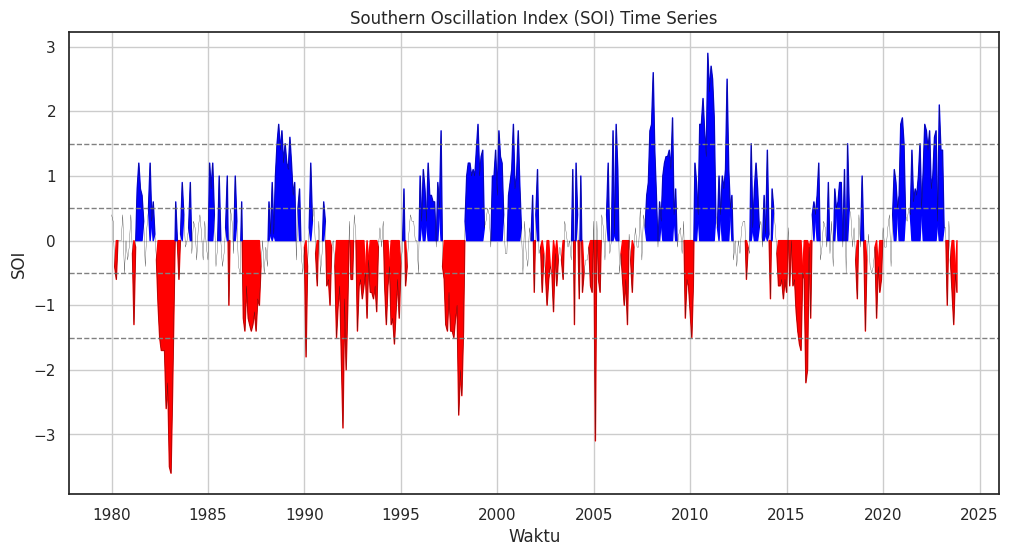

In [ ]:
excel_file = '/content/soi.xlsx'
df = pd.read_excel(excel_file, sheet_name='sois')

df_melted = pd.melt(df, id_vars=['YEAR'], var_name='Month', value_name='SOI')

df_melted['Date'] = pd.to_datetime(df_melted['YEAR'].astype(str) + '-' + df_melted['Month'], format='%Y-%b')
df_melted.sort_values(by='Date', inplace=True)
df_melted = df_melted[df_melted['Date'].dt.year >= 1980]

sns.set(style="white")
plt.figure(figsize=(12, 6))

plt.fill_between(df_melted['Date'], df_melted['SOI'], where=(df_melted['SOI'] < -0.5), color='red', interpolate=True)
plt.fill_between(df_melted['Date'], df_melted['SOI'], where=(df_melted['SOI'] > 0.5), color='blue', interpolate=True)
#plt.fill_between(df_melted['Date'], -0.5, 0.5, color='white')

#plt.axhline(y=-0.5, color='gray', linestyle='--', linewidth=1)
#plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
#plt.axhline(y=-1.5, color='gray', linestyle='--', linewidth=1)
#plt.axhline(y=1.5, color='gray', linestyle='--', linewidth=1)
plt.plot(df_melted['Date'], df_melted['SOI'], linestyle='-', linewidth=0.2, color='k', alpha=1)

plt.title('Standardized Southern Oscillation Index (SOI) Time Series')
plt.xlabel('Waktu')
plt.ylabel('SOI')
plt.grid(True)
plt.show()

In [ ]:
df_melted

https://www.jamstec.go.jp/aplinfo/sintexf/elnmodoki/images/modoki_02.jpg